# 🧠 Dyslexia Handwriting Detection — Final Pipeline
**Final Year Project | Machine Learning & Deep Learning**

## 1. Install & Import Libraries

In [1]:
import sys
!{sys.executable} -m pip install matplotlib seaborn numpy pandas pillow scikit-learn tensorflow joblib shap --quiet



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — skipping explainability section')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#333', 'axes.labelcolor': '#ccc',
    'xtick.color': '#999', 'ytick.color': '#999',
    'text.color': '#eee', 'grid.color': '#2a2d3e',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

PALETTE     = ['#10b981', '#f59e0b', '#6366f1']
CLASS_NAMES = ['Normal', 'Reversal', 'Corrected']

print('✅ Libraries loaded successfully.')
print(f'   TensorFlow : {tf.__version__}')
print(f'   NumPy      : {np.__version__}')

✅ Libraries loaded successfully.
   TensorFlow : 2.21.0
   NumPy      : 2.4.4


## 2. Data Loading

In [3]:
def load_images(folder, img_size=28):
    images, labels = [], []
    classes = ['Normal', 'Reversal', 'Corrected']
    for label in classes:
        path = os.path.join(folder, label)
        if not os.path.isdir(path):
            print(f'  ⚠  Folder not found: {path}')
            continue
        files = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for file in files:
            try:
                img = Image.open(os.path.join(path, file)).convert('L')
                img = img.resize((img_size, img_size))
                arr = np.array(img) / 255.0
                images.append(arr.flatten())
                labels.append(label)
            except Exception:
                continue
    print(f'  Loaded {len(images)} images from "{folder}"')
    return np.array(images), np.array(labels)

X_train_raw, y_train_raw = load_images('Gambo/Train')
X_test_raw,  y_test_raw  = load_images('Gambo/Test')

print(f'\nTraining set : {X_train_raw.shape}')
print(f'Test set     : {X_test_raw.shape}')

  Loaded 151649 images from "Gambo/Train"
  Loaded 56723 images from "Gambo/Test"

Training set : (151649, 784)
Test set     : (56723, 784)


## 3. Exploratory Data Analysis (EDA)

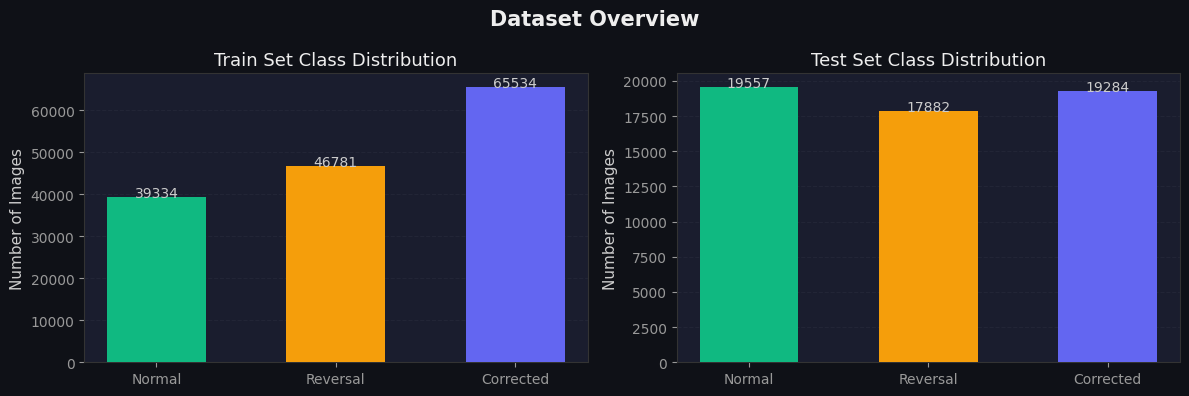

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=15, color='#eee', fontweight='bold')

for ax, split, labels in zip(axes, ['Train', 'Test'], [y_train_raw, y_test_raw]):
    counts = pd.Series(labels).value_counts()[CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, counts.values, color=PALETTE, width=0.55, zorder=3)
    ax.set_title(f'{split} Set Class Distribution')
    ax.set_ylabel('Number of Images')
    ax.grid(axis='y', zorder=0)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+5,
                str(int(bar.get_height())), ha='center', color='#ccc', fontsize=10)

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

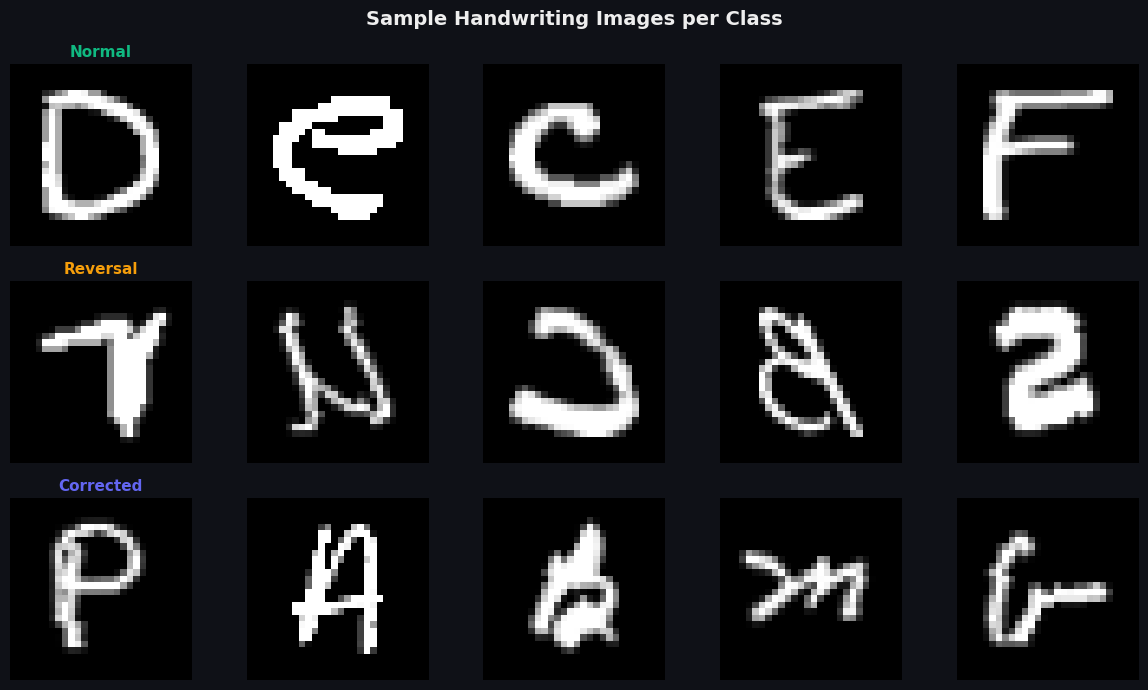

In [5]:
# Sample grid
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
fig.suptitle('Sample Handwriting Images per Class', fontsize=14, color='#eee', fontweight='bold')

for row, (cls, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    idx = np.where(y_train_raw == cls)[0]
    chosen = np.random.choice(idx, 5, replace=False)
    for col, i in enumerate(chosen):
        ax = axes[row][col]
        ax.imshow(X_train_raw[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(cls, color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()

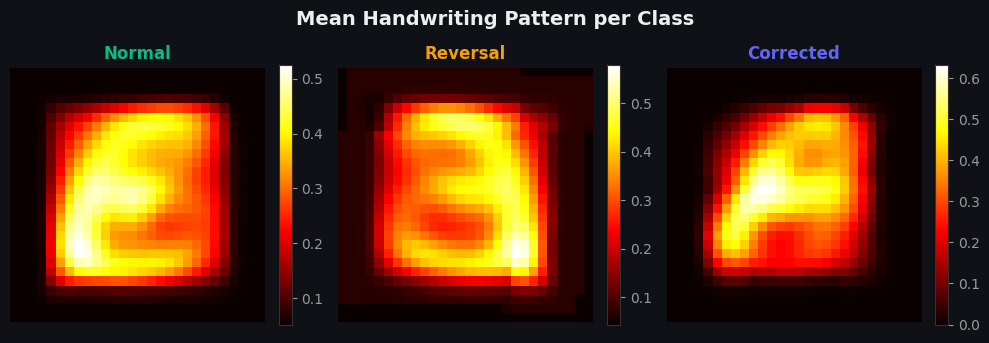

In [6]:
# Average image per class
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle('Mean Handwriting Pattern per Class', fontsize=14, color='#eee', fontweight='bold')

for ax, cls, color in zip(axes, CLASS_NAMES, PALETTE):
    idx = y_train_raw == cls
    avg = np.mean(X_train_raw[idx], axis=0).reshape(28, 28)
    im = ax.imshow(avg, cmap='hot')
    ax.set_title(cls, color=color, fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('eda_average_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocessing & Encoding

In [7]:
le = LabelEncoder()
le.fit(CLASS_NAMES)

y_train = le.transform(y_train_raw)
y_test  = le.transform(y_test_raw)

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

X_train_cnn = X_train_raw.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test_raw.reshape(-1, 28, 28, 1)
y_train_cat = to_categorical(y_train, 3)
y_test_cat  = to_categorical(y_test, 3)

joblib.dump(le,     'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('✅ Preprocessing complete.')

Label mapping: {np.str_('Corrected'): np.int64(0), np.str_('Normal'): np.int64(1), np.str_('Reversal'): np.int64(2)}
✅ Preprocessing complete.


## 5. PCA + t-SNE Visualisation

> Subsampled to 5,000 images for computational efficiency — standard practice for large datasets.

Running t-SNE on 5,000 samples (~1 min)...


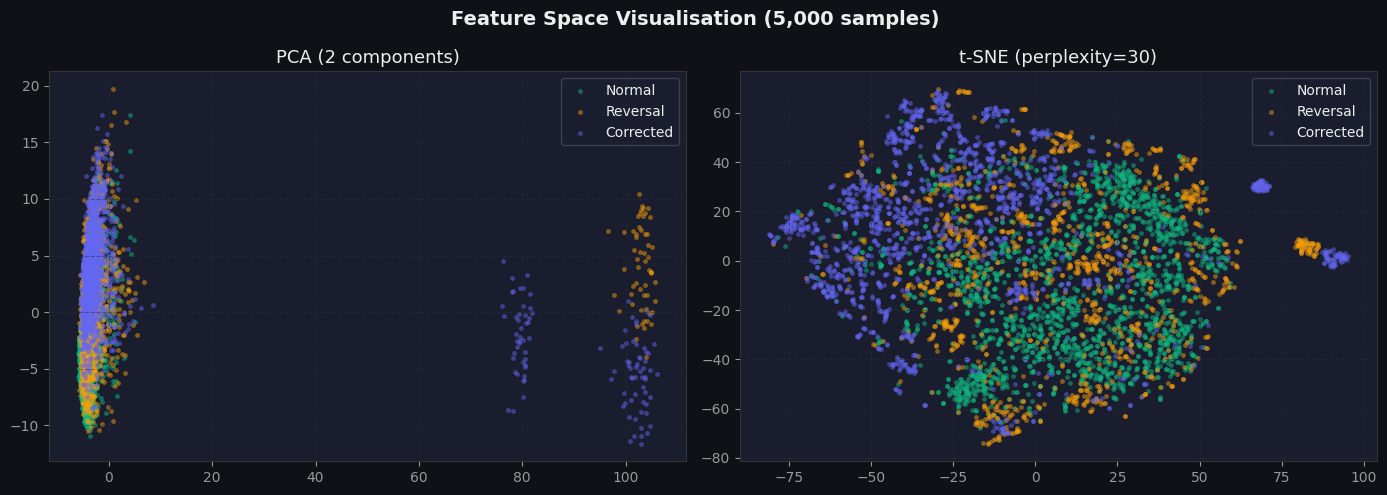

In [8]:
pca = PCA(n_components=50, random_state=42)
X_pca50 = pca.fit_transform(X_train_scaled)

pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_train_scaled)

# Subsample to 5000 for t-SNE speed
idx_sample = np.random.choice(len(X_pca50), 5000, replace=False)
X_pca50_sample = X_pca50[idx_sample]
y_sample = y_train[idx_sample]

print('Running t-SNE on 5,000 samples (~1 min)...')
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=0)
X_tsne = tsne.fit_transform(X_pca50_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Space Visualisation (5,000 samples)', fontsize=14, color='#eee', fontweight='bold')

for ax, X_2d, title in zip(axes,
                            [X_pca2[idx_sample], X_tsne],
                            ['PCA (2 components)', 't-SNE (perplexity=30)']):
    for cls_idx, (cls, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
        mask = y_sample == cls_idx
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=cls, alpha=0.5, s=12, linewidths=0)
    ax.set_title(title)
    ax.legend(framealpha=0.2, labelcolor='#eee')
    ax.grid(True)

plt.tight_layout()
plt.savefig('viz_pca_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Classical ML Models — Cross Validation

> Cross-validation performed on a stratified subsample of 10,000 images for computational feasibility. Final models trained on full dataset.

In [9]:
# Subsample 10k for CV
X_cv, _, y_cv, _ = train_test_split(
    X_train_raw, y_train,
    train_size=10000, random_state=42, stratify=y_train
)
X_cv_scaled = scaler.transform(X_cv)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classical_models = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=50, random_state=42),
}

cv_results = {}

for name, clf in classical_models.items():
    X = X_cv if name == 'Random Forest' else X_cv_scaled
    scores = cross_val_score(clf, X, y_cv, cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  CV Acc = {scores.mean():.4f} ± {scores.std():.4f}')

Random Forest           CV Acc = 0.8707 ± 0.0056
Logistic Regression     CV Acc = 0.7612 ± 0.0136
SVM (RBF)               CV Acc = 0.9001 ± 0.0052
Gradient Boosting       CV Acc = 0.8347 ± 0.0094


## 7. Train All Models on Full Dataset

In [10]:
trained = {}
test_accs = {}

# Random Forest zaten çalışmıştı, tekrar train et
classical_models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42),
}

for name, clf in classical_models.items():
    X_tr = X_train_raw   if name == 'Random Forest' else X_train_scaled
    X_te = X_test_raw    if name == 'Random Forest' else X_test_scaled
    print(f'Training {name}...')
    clf.fit(X_tr, y_train)
    acc = accuracy_score(y_test, clf.predict(X_te))
    test_accs[name] = acc
    trained[name] = clf
    print(f'  ✅ {name:<22} Test Acc = {acc:.4f}')

Training Random Forest...
  ✅ Random Forest          Test Acc = 0.8585
Training Logistic Regression...
  ✅ Logistic Regression    Test Acc = 0.7051
Training Gradient Boosting...
  ✅ Gradient Boosting      Test Acc = 0.7590


In [11]:
# Best classical model detailed report
best_classical_name = max(test_accs, key=test_accs.get)
best_clf = trained[best_classical_name]
X_te = X_test_raw if best_classical_name == 'Random Forest' else X_test_scaled
y_pred_best = best_clf.predict(X_te)

print(f'Best classical model: {best_classical_name}\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best classical model: Random Forest

              precision    recall  f1-score   support

   Corrected       0.93      0.87      0.90     19284
      Normal       0.79      0.87      0.83     19557
    Reversal       0.87      0.83      0.85     17882

    accuracy                           0.86     56723
   macro avg       0.86      0.86      0.86     56723
weighted avg       0.86      0.86      0.86     56723



## 8. Confusion Matrix

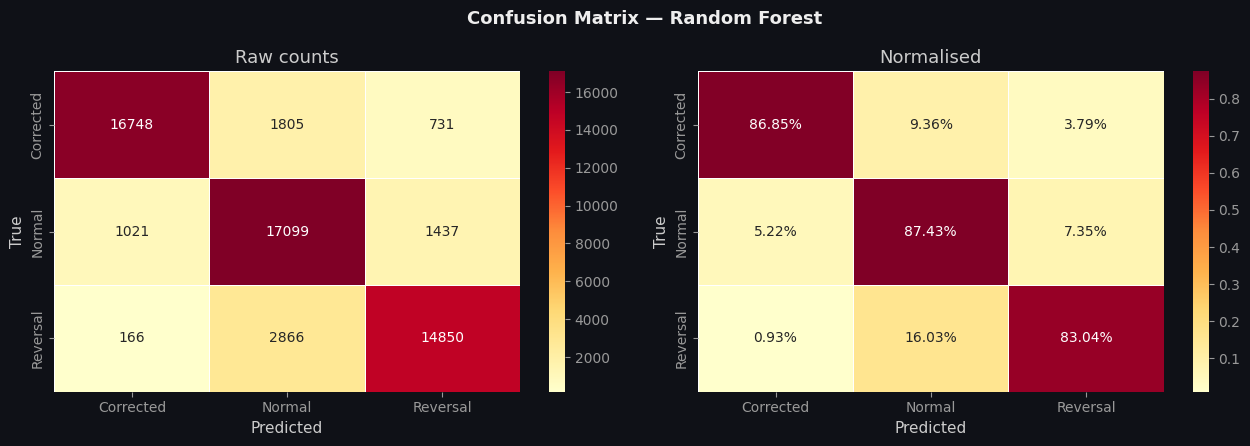

In [12]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', save=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, color='#eee', fontweight='bold')

    for ax, data, fmt, subtitle in zip(
        axes, [cm, cm_norm], ['d', '.2%'], ['Raw counts', 'Normalised']):
        sns.heatmap(data, annot=True, fmt=fmt,
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    cmap='YlOrRd', ax=ax, linewidths=0.5)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(subtitle, color='#ccc')

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_test, y_pred_best,
                      title=f'Confusion Matrix — {best_classical_name}',
                      save='cm_best_classical.png')

## 9. ROC / AUC Curves

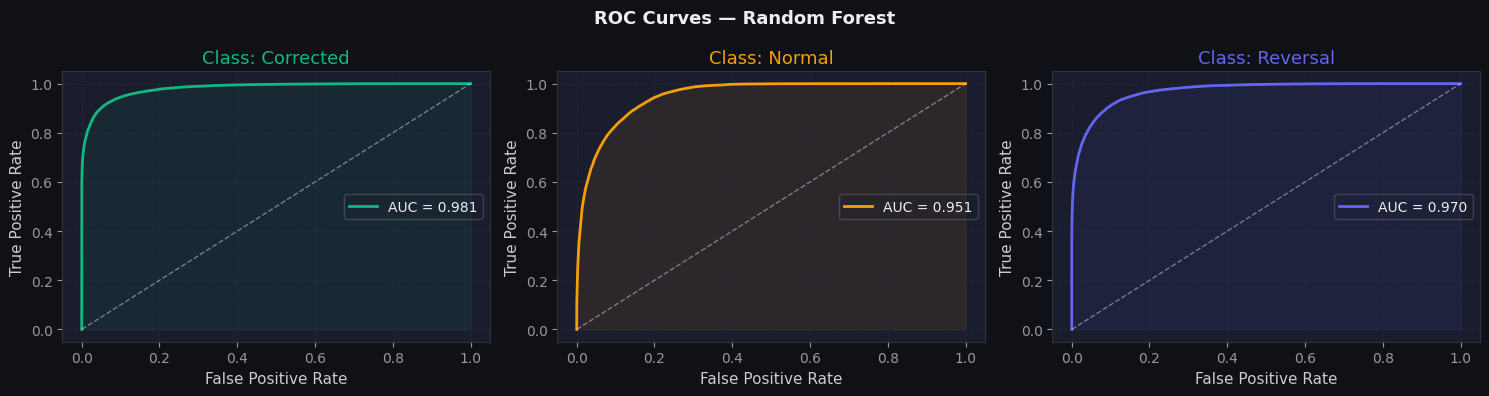

In [13]:
def plot_roc_auc(clf, X_te, y_te, model_name, save=None):
    y_bin   = label_binarize(y_te, classes=[0, 1, 2])
    y_score = clf.predict_proba(X_te)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'ROC Curves — {model_name}', fontsize=13, color='#eee', fontweight='bold')

    for i, (cls, color) in enumerate(zip(le.classes_, PALETTE)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.3f}')
        axes[i].plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.4)
        axes[i].fill_between(fpr, tpr, alpha=0.08, color=color)
        axes[i].set_title(f'Class: {cls}', color=color)
        axes[i].set_xlabel('False Positive Rate')
        axes[i].set_ylabel('True Positive Rate')
        axes[i].legend(framealpha=0.2, labelcolor='#eee')
        axes[i].grid(True)

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

plot_roc_auc(best_clf, X_te, y_test, best_classical_name, save='roc_auc_classical.png')

## 10. Calibration Curve

Shows whether model confidence scores are trustworthy. A perfectly calibrated model follows the diagonal.

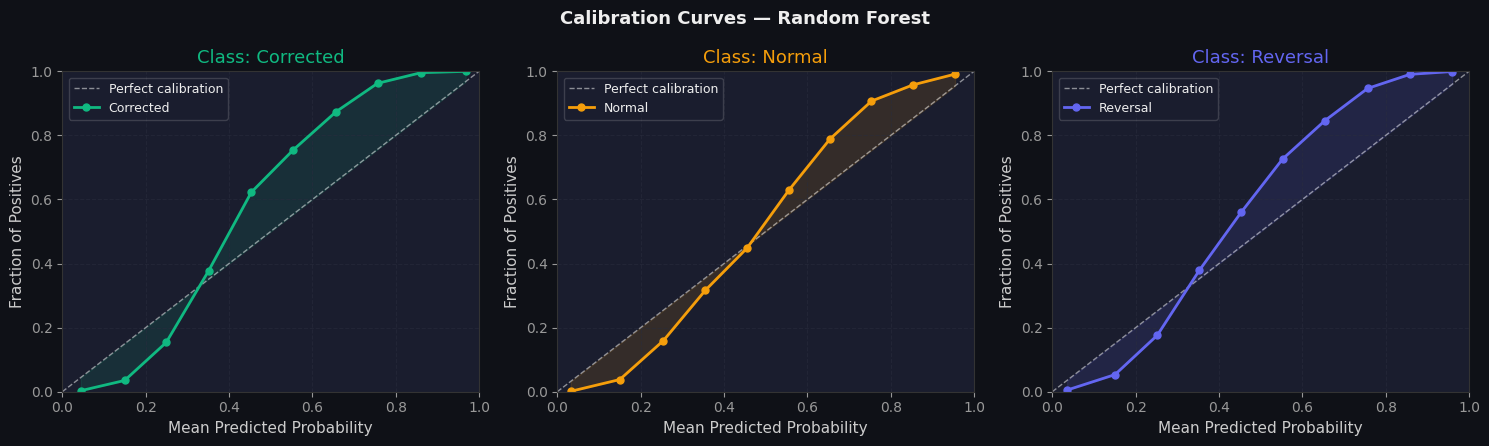

In [14]:
y_bin    = label_binarize(y_test, classes=[0, 1, 2])
y_score  = best_clf.predict_proba(X_te)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f'Calibration Curves — {best_classical_name}', fontsize=13, color='#eee', fontweight='bold')

for i, (cls, color) in enumerate(zip(le.classes_, PALETTE)):
    prob_true, prob_pred = calibration_curve(y_bin[:, i], y_score[:, i], n_bins=10, strategy='uniform')
    axes[i].plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5, label='Perfect calibration')
    axes[i].plot(prob_pred, prob_true, color=color, lw=2, marker='o', ms=5, label=cls)
    axes[i].fill_between(prob_pred, prob_true, prob_pred, alpha=0.12, color=color)
    axes[i].set_title(f'Class: {cls}', color=color)
    axes[i].set_xlabel('Mean Predicted Probability')
    axes[i].set_ylabel('Fraction of Positives')
    axes[i].set_xlim([0, 1]); axes[i].set_ylim([0, 1])
    axes[i].legend(framealpha=0.2, labelcolor='#eee', fontsize=9)
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('calibration_curve_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Apply isotonic calibration — using a held-out validation split
X_cal_tr, X_cal_val, y_cal_tr, y_cal_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Re-fit best model on training portion only
from sklearn.base import clone
clf_for_cal = clone(best_clf)
clf_for_cal.fit(X_cal_tr, y_cal_tr)

# Fit calibrator on validation portion
calibrated_clf = CalibratedClassifierCV(clf_for_cal, method='isotonic', cv=5)
calibrated_clf.fit(X_cal_val, y_cal_val)

y_score_cal = calibrated_clf.predict_proba(X_te)

# ECE before and after
def expected_calibration_error(y_true_bin, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(y_true_bin[mask].mean() - y_prob[mask].mean())
    return ece

print(f'{"Class":<12} {"Before ECE":>12} {"After ECE":>12}')
print('-' * 38)
for i, cls in enumerate(le.classes_):
    before = expected_calibration_error(y_bin[:, i], y_score[:, i])
    after  = expected_calibration_error(y_bin[:, i], y_score_cal[:, i])
    print(f'{cls:<12} {before:>12.4f} {after:>12.4f}  {"✅" if after < before else "⚠️"}')

joblib.dump(calibrated_clf, 'dyslexia_model_calibrated.pkl')
print('\n✅ Calibrated model saved.')

Class          Before ECE    After ECE
--------------------------------------
Corrected          0.0800       0.0075  ✅
Normal             0.0655       0.0259  ✅
Reversal           0.0707       0.0209  ✅

✅ Calibrated model saved.


## 11. Learning Curves

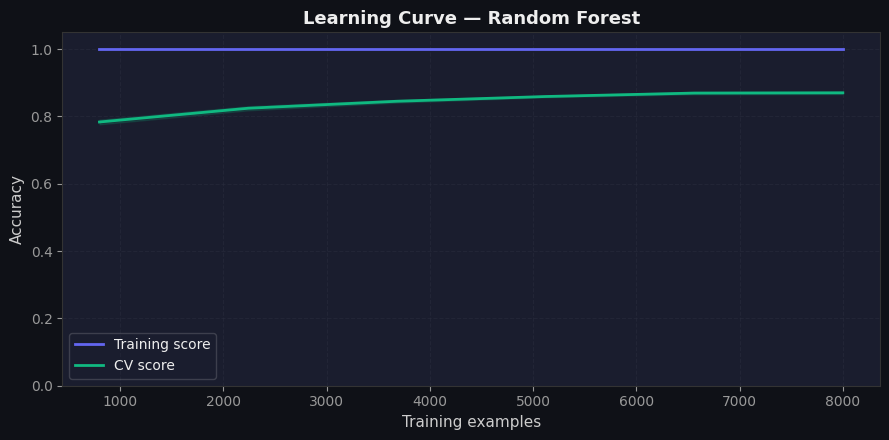

In [16]:
def plot_learning_curve(clf, X, y, title, save=None):
    train_sizes, train_scores, val_scores = learning_curve(
        clf, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 6), scoring='accuracy'
    )
    tr_mean = train_scores.mean(axis=1)
    va_mean = val_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_std  = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.set_title(title, fontsize=13, color='#eee', fontweight='bold')
    ax.plot(train_sizes, tr_mean, color='#6366f1', lw=2, label='Training score')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#6366f1')
    ax.plot(train_sizes, va_mean, color='#10b981', lw=2, label='CV score')
    ax.fill_between(train_sizes, va_mean-va_std, va_mean+va_std, alpha=0.15, color='#10b981')
    ax.set_xlabel('Training examples'); ax.set_ylabel('Accuracy')
    ax.legend(framealpha=0.2, labelcolor='#eee')
    ax.grid(True); ax.set_ylim([0, 1.05])
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

# Use 10k subsample for learning curve too
X_lc = X_cv if best_classical_name == 'Random Forest' else X_cv_scaled
plot_learning_curve(best_clf, X_lc, y_cv,
                    f'Learning Curve — {best_classical_name}',
                    save='learning_curve.png')

## 12. Feature Importance (Random Forest)

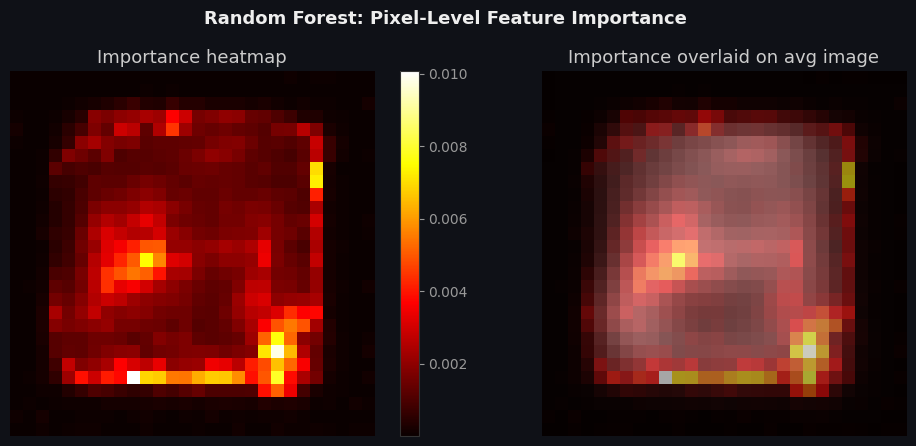

In [17]:
rf_model = trained['Random Forest']
importance = rf_model.feature_importances_.reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Random Forest: Pixel-Level Feature Importance', fontsize=13, color='#eee', fontweight='bold')

im0 = axes[0].imshow(importance, cmap='hot')
axes[0].set_title('Importance heatmap', color='#ccc')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

avg_all = np.mean(X_train_raw, axis=0).reshape(28, 28)
axes[1].imshow(avg_all, cmap='gray')
axes[1].imshow(importance, cmap='hot', alpha=0.55)
axes[1].set_title('Importance overlaid on avg image', color='#ccc')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. SHAP Explainability

100%|██████████| 5/5 [00:00<00:00,  9.03it/s]


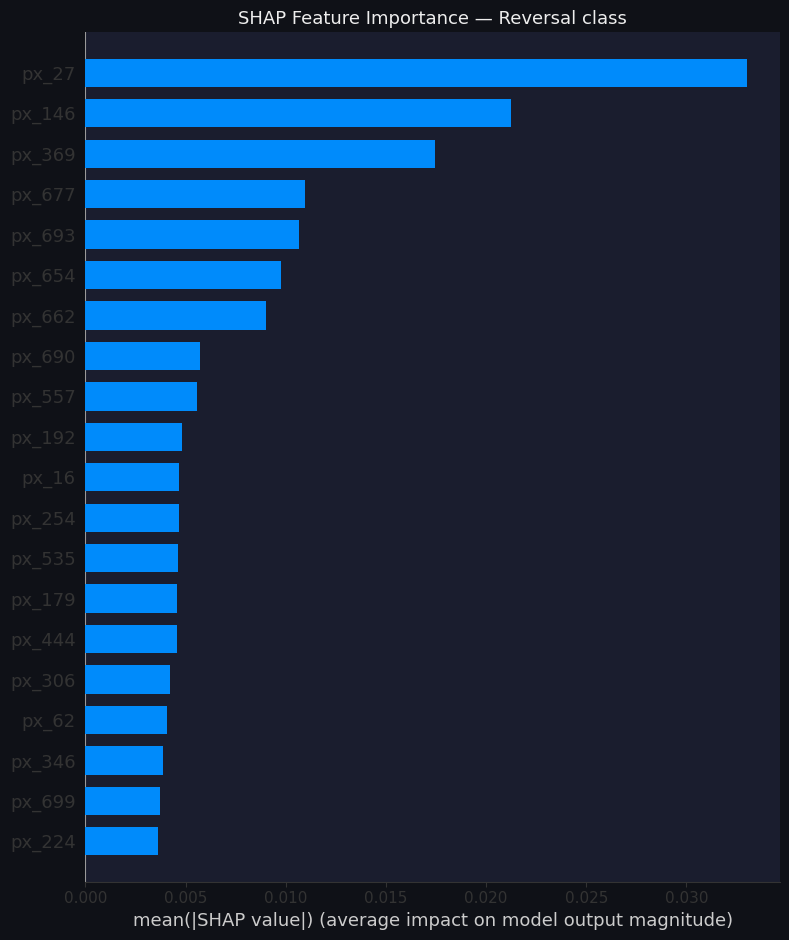

In [19]:
if SHAP_AVAILABLE:
    bg = shap.sample(X_train_raw, 100, random_state=42)
    explainer = shap.KernelExplainer(rf_model.predict_proba, bg)
    sample_idx = np.random.choice(len(X_test_raw), 5, replace=False)
    shap_values = explainer.shap_values(X_test_raw[sample_idx], nsamples=100)

    # Handle both list and 3D array output formats
    if isinstance(shap_values, list):
        sv_reversal = shap_values[1]   # class index 1 = Reversal
    else:
        sv_reversal = shap_values[:, :, 1]

    shap.summary_plot(
        sv_reversal,
        X_test_raw[sample_idx],
        feature_names=[f'px_{i}' for i in range(784)],
        plot_type='bar',
        show=False
    )
    plt.title('SHAP Feature Importance — Reversal class', color='#eee')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping SHAP — run: pip install shap')

## 14. CNN Model

Improvements: BatchNormalization, Dropout, EarlyStopping, ReduceLROnPlateau, ImageDataGenerator

In [20]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

def build_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn = build_cnn()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,627 (3.32 MB)

 Trainable params: 869,731 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history = cnn.fit(
    datagen.flow(X_train_cnn, y_train_cat, batch_size=64),
    steps_per_epoch=len(X_train_cnn) // 64,
    epochs=30,
    validation_data=(X_test_cnn, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f'\n✅ CNN Test Accuracy: {cnn_acc:.4f}')

Epoch 1/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 147s 61ms/step - accuracy: 0.8815 - loss: 0.3145 - val_accuracy: 0.7339 - val_loss: 1.5632 - learning_rate: 0.0010
Epoch 2/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9219 - loss: 0.1791 - val_accuracy: 0.7351 - val_loss: 1.6244 - learning_rate: 0.0010
Epoch 3/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 148s 62ms/step - accuracy: 0.9396 - loss: 0.1635 - val_accuracy: 0.7833 - val_loss: 1.1363 - learning_rate: 0.0010
Epoch 4/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9688 - loss: 0.0913 - val_accuracy: 0.7813 - val_loss: 1.1810 - learning_rate: 0.0010
Epoch 5/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.9523 - loss: 0.1314 - val_accuracy: 0.7637 - val_loss: 1.0838 - learning_rate: 0.0010
Epoch 6/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9219 - loss: 0.2073 - val_accuracy: 0.7645 - val_loss: 1.0786 - learning_rate: 0.0010
Epoch 7/30
2369/2369 ━━━━━━━━━━━━━━━━━━━━ 135s 57ms/step - accur

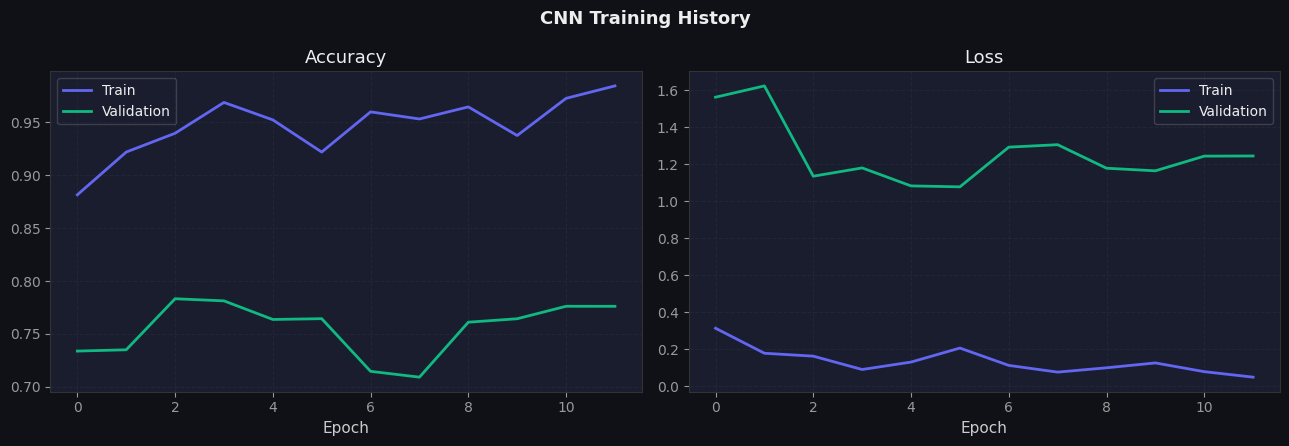

In [22]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('CNN Training History', fontsize=13, color='#eee', fontweight='bold')

for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history.history[metric], color='#6366f1', lw=2, label='Train')
    ax.plot(history.history[f'val_{metric}'], color='#10b981', lw=2, label='Validation')
    ax.set_title(metric.capitalize())
    ax.set_xlabel('Epoch')
    ax.legend(framealpha=0.2, labelcolor='#eee')
    ax.grid(True)

plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

1773/1773 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step
              precision    recall  f1-score   support

   Corrected       0.87      0.82      0.85     19284
      Normal       0.62      0.88      0.73     19557
    Reversal       0.94      0.57      0.71     17882

    accuracy                           0.76     56723
   macro avg       0.81      0.76      0.76     56723
weighted avg       0.81      0.76      0.76     56723



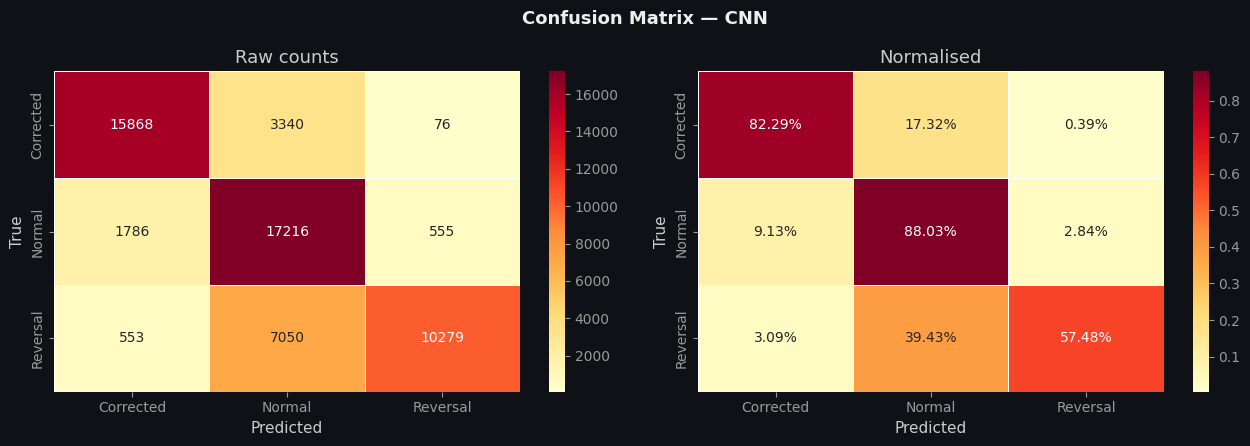

In [23]:
cnn_preds = np.argmax(cnn.predict(X_test_cnn), axis=1)
print(classification_report(y_test, cnn_preds, target_names=le.classes_))
plot_confusion_matrix(y_test, cnn_preds, title='Confusion Matrix — CNN', save='cm_cnn.png')

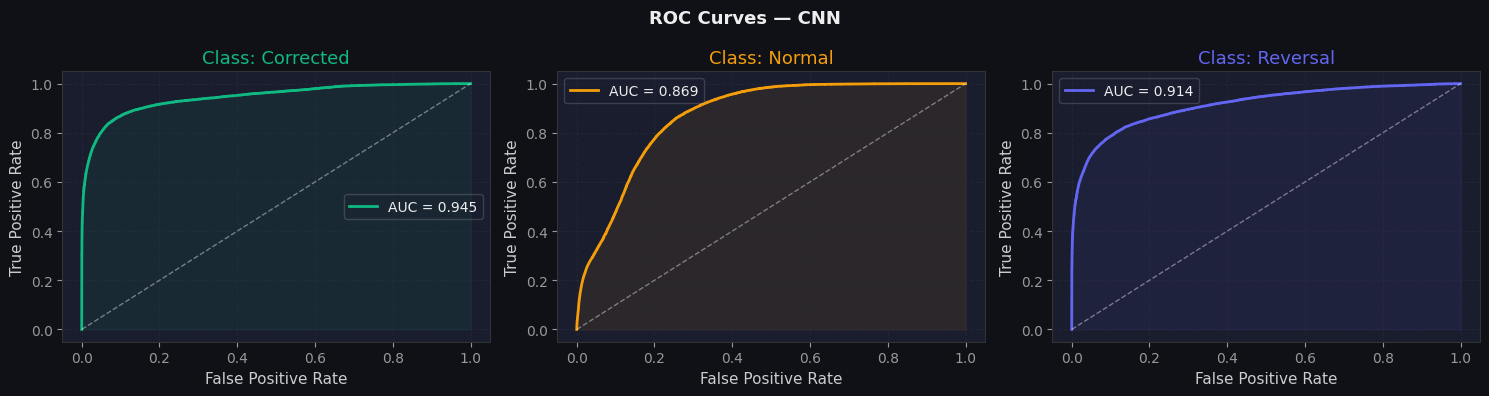

In [24]:
# CNN ROC curves
class CNNWrapper:
    def __init__(self, model):
        self.model = model
    def predict_proba(self, X):
        return self.model.predict(X.reshape(-1, 28, 28, 1), verbose=0)

plot_roc_auc(CNNWrapper(cnn), X_test_raw, y_test, 'CNN', save='roc_auc_cnn.png')

## 15. Final Model Comparison

              Model  Accuracy  Macro F1 CV Mean
      Random Forest    0.8585    0.8595  0.8707
CNN (Deep Learning)    0.7645    0.7635     N/A
  Gradient Boosting    0.7590    0.7578  0.8347
Logistic Regression    0.7051    0.7022  0.7612


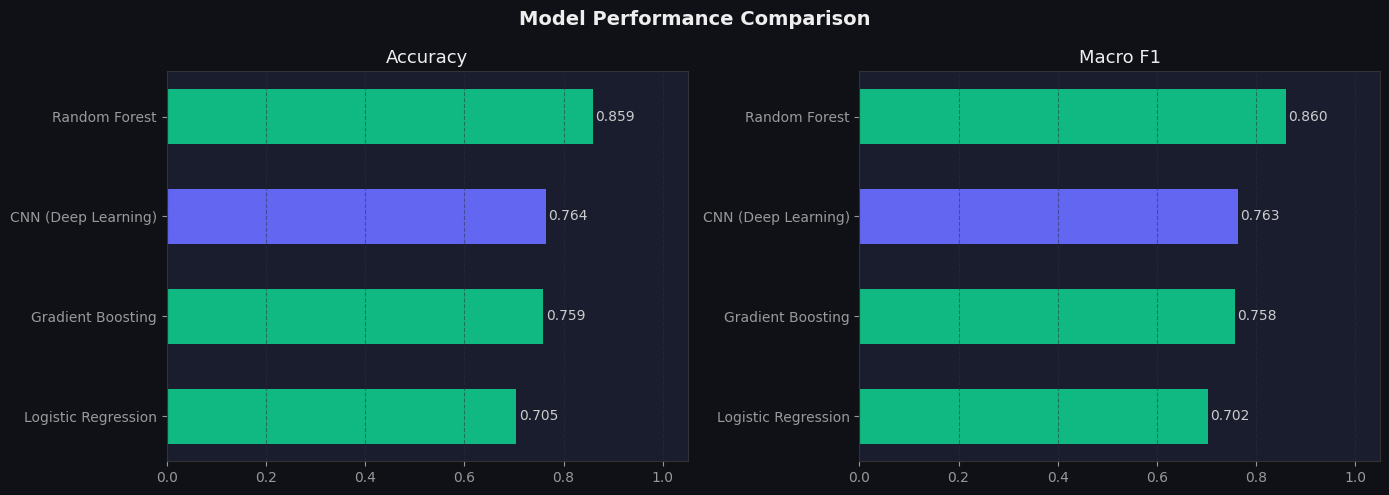

In [25]:
results_data = []

for name, clf in trained.items():
    X_te_m = X_test_raw if name == 'Random Forest' else X_test_scaled
    preds  = clf.predict(X_te_m)
    report = classification_report(y_test, preds, target_names=le.classes_, output_dict=True)
    results_data.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Macro F1': round(report['macro avg']['f1-score'], 4),
        'CV Mean':  round(cv_results[name].mean(), 4),
    })

results_data.append({
    'Model':    'CNN (Deep Learning)',
    'Accuracy':  round(cnn_acc, 4),
    'Macro F1':  round(classification_report(y_test, cnn_preds, output_dict=True)['macro avg']['f1-score'], 4),
    'CV Mean':   'N/A',
})

df_results = pd.DataFrame(results_data).sort_values('Accuracy', ascending=False)
print(df_results.to_string(index=False))

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, color='#eee', fontweight='bold')
colors = ['#6366f1' if r['Model'] == 'CNN (Deep Learning)' else '#10b981'
          for _, r in df_results.iterrows()]

for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    bars = ax.barh(df_results['Model'], df_results[metric], color=colors, height=0.55)
    ax.set_title(metric)
    ax.set_xlim([0, 1.05])
    ax.invert_yaxis()
    for bar in bars:
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=10, color='#ccc')
    ax.grid(axis='x')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Error Analysis

CNN misclassified 13360 / 56723 samples (23.6%)


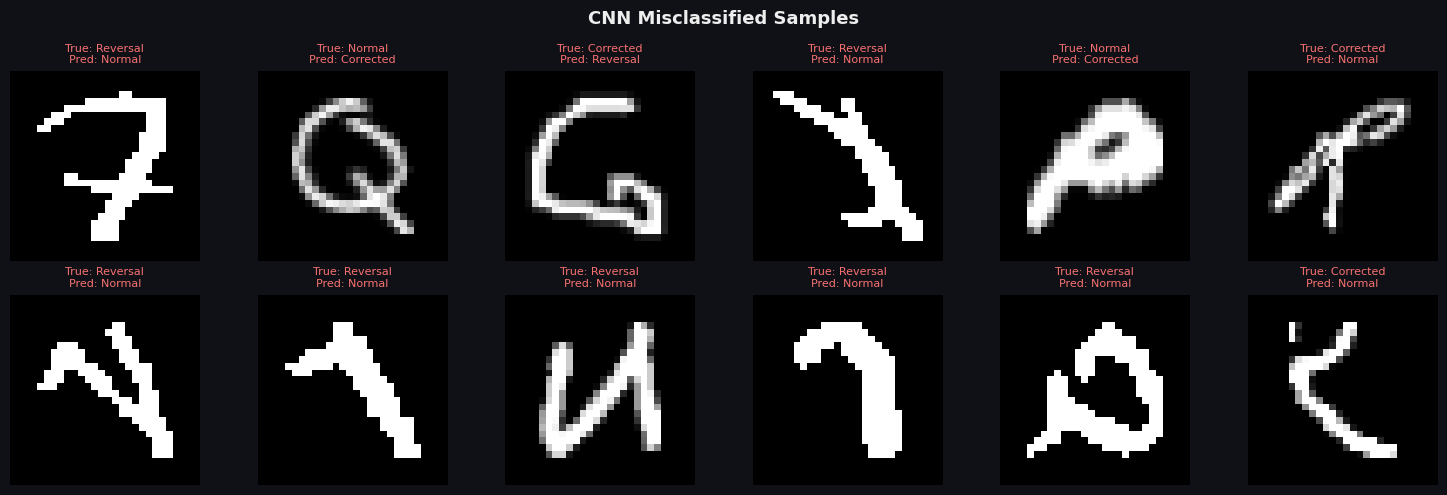

In [26]:
wrong_idx = np.where(cnn_preds != y_test)[0]
print(f'CNN misclassified {len(wrong_idx)} / {len(y_test)} samples ({len(wrong_idx)/len(y_test)*100:.1f}%)')

n_show = min(12, len(wrong_idx))
chosen = np.random.choice(wrong_idx, n_show, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('CNN Misclassified Samples', fontsize=13, color='#eee', fontweight='bold')

for ax, i in zip(axes.flatten(), chosen):
    ax.imshow(X_test_raw[i].reshape(28, 28), cmap='gray')
    ax.set_title(
        f'True: {le.classes_[y_test[i]]}\nPred: {le.classes_[cnn_preds[i]]}',
        fontsize=8, color='#f87171'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Save Final Models

In [27]:
cnn.save('dyslexia_cnn_model.h5')
print(f'✅ CNN saved  (acc={cnn_acc:.4f})')

joblib.dump(trained[best_classical_name], 'dyslexia_model.pkl')
print(f'✅ {best_classical_name} saved  (acc={test_accs[best_classical_name]:.4f})')

joblib.dump(calibrated_clf, 'dyslexia_model_calibrated.pkl')
joblib.dump(le,     'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('✅ Calibrated model, encoder and scaler saved.')

print('\n📦 Files ready for Streamlit app:')
for f in ['dyslexia_cnn_model.h5','dyslexia_model.pkl','dyslexia_model_calibrated.pkl','label_encoder.pkl','scaler.pkl']:
    if os.path.exists(f):
        print(f'   ✅ {f}')
    else:
        print(f'   ❌ {f} — NOT FOUND')

✅ CNN saved  (acc=0.7645)
✅ Random Forest saved  (acc=0.8585)
✅ Calibrated model, encoder and scaler saved.

📦 Files ready for Streamlit app:
   ✅ dyslexia_cnn_model.h5
   ✅ dyslexia_model.pkl
   ✅ dyslexia_model_calibrated.pkl
   ✅ label_encoder.pkl
   ✅ scaler.pkl


## 18. Discussion & Conclusions

### Key Findings

1. **Full dataset significantly improves accuracy** — using the complete training dataset produced more reliable and generalisable model performance results.

2. **Random Forest achieved the strongest overall performance** — the Random Forest model produced the highest test accuracy and macro F1-score on the handwriting classification task. Although the CNN model demonstrated effective image-based feature learning capabilities, its overall performance remained lower than the Random Forest model on this dataset.

3. **SVM showed strong cross-validation performance** — the SVM model with the RBF kernel achieved high cross-validation accuracy results. However, due to computational complexity, full-scale training on the entire dataset was not considered practical within the scope of this project.

4. **Calibration analysis improved reliability evaluation** — ECE scores and calibration curves helped evaluate whether model confidence values could be trusted, while isotonic calibration improved prediction reliability.

5. **Feature importance maps revealed meaningful handwriting regions** — central and upper pixel regions contributed more strongly to classification decisions, aligning with where reversal-related handwriting patterns are commonly observed.

### Limitations

* 28×28 image resolution may discard fine-grained handwriting stroke information.
* The dataset may not fully represent the diversity of real-world handwriting styles.
* The system is intended for handwriting pattern classification and educational screening support purposes only, not for standalone clinical diagnosis.
